In [1]:
# Put import statements here
import os
# hide tensorflow info/warning logs
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import sys
import subprocess
from pathlib import Path


# Local files/code
import src.data_preprocessing.image_preprocessing as img_pre
import src.data_preprocessing.text_preprocessing as text_pre
import src.data_preprocessing.text_data_exploration as text_explore
from src.agents.Visual_Agent import VisualModel
from src.util.logger import Logger
from src.util.config import config, PROJECT_ROOT
import src.util.general as general_util
from src.data_preprocessing.TextTokenizer import TextTokenizer
from src.data_preprocessing.TextEmbedder import TextEmbedder
from src.data_preprocessing.USDA_processing import process_USDA_plant_sheets


In [2]:
# Determine the project's data repo location
DATA_DIR= PROJECT_ROOT / "data"


In [3]:
# Chunk and vectorize the USDA plant sheets

USDA_data_path= DATA_DIR / "EOI_Data_Pulls"

# make the text embedder that will vectorize the text
embedder= TextEmbedder("sentence-transformers/all-MiniLM-L6-v2")

CHUNK_METHOD= "word" # word or sentence
CHUNK_MAX_SIZE= 64
CHUNK_OVERLAP_AMOUNT= 16

# This takes ~30sec - 1.5min to run
# parse the USDA plant sheets, chunk them, vectorize them, and make organized records
# NOTE: the PDF parsing library loves to spit out annoying logs
#       I've tried to supress them a million ways, but could not get it to stop
#       The logs are annoying but superficial
records= process_USDA_plant_sheets(
    USDA_data_path, 
    embedder, 
    CHUNK_METHOD, 
    CHUNK_MAX_SIZE, 
    CHUNK_OVERLAP_AMOUNT
)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

MuPDF error: format error: No default Layer config

MuPDF error: format error: No default Layer config

21:52:34 [WARNING ]: Plant name is none, using plant code instead
MuPDF error: format error: No default Layer config

MuPDF error: format error: No default Layer config

MuPDF error: format error: No default Layer config

MuPDF error: format error: No default Layer config

MuPDF error: format error: No default Layer config

MuPDF error: format error: No default Layer config

MuPDF error: format error: No default Layer config

MuPDF error: format error: No default Layer config

MuPDF error: format error: No default Layer config

MuPDF error: format error: No default Layer config

MuPDF error: format error: No default Layer config

MuPDF error: format error: No default Layer config

MuPDF error: format error: No default Layer config

MuPDF error: format error: No default Layer config

MuPDF error: format error: No default Layer config

MuPDF error: format error: No default Layer config

In [4]:
# Example of one of the records for one chunk of a plant 
Logger.info(f"records type: {type(records)}")
Logger.info(f"records len: {len(records)}")
Logger.info(f"Example of a chunk record: \n\n{records['common yarrow'][0]}")

21:53:03 [INFO    ]: records type: <class 'dict'>
21:53:03 [INFO    ]: records len: 209
21:53:03 [INFO    ]: Example of a chunk record: 

Text: Contributed by: Caution: This plant may become inv...
Embedding: [-0.03075747936964035, 0.02351946383714676, -0.06517548114061356, -0.0018471790244802833, -0.02429845556616783, '...']
Metadata: {'symbol': 'ACMI2', 'scientific_name': 'Achillea millefolium L.', 'rank': 'Species', 'group': 'Dicot', 'common_name': 'common yarrow', 'other_common_names': ['milenrama', 'milfoil'], 'durations': ['Perennial'], 'growth_habits': ['Forb/herb'], 'fact_sheet_urls': [], 'plant_guide_urls': ['/DocumentLibrary/plantguide/doc/cs_acmi2.docx', '/DocumentLibrary/plantguide/pdf/cs_acmi2.pdf', '/DocumentLibrary/plantguide/pdf/pg_acmi2.pdf'], 'native_regions': [{'region': 'AK', 'status': 'Native'}, {'region': 'CAN', 'status': 'Introduced'}, {'region': 'CAN', 'status': 'Native'}, {'region': 'GL', 'status': 'Native'}, {'region': 'HI', 'status': 'Introduced'}, {'region':

In [5]:
# load the plantExpertVQA training, validation, and testing datasets
plant_expert_vqa_data_path= DATA_DIR / config.data.PlantExpertVQA.data_path
plant_expert_vqa_path= DATA_DIR / "PlantExpertVQA"
train_data_path= plant_expert_vqa_data_path / config.data.PlantExpertVQA.train_file
test_data_path= plant_expert_vqa_data_path / config.data.PlantExpertVQA.test_file
validation_data_path= plant_expert_vqa_data_path / config.data.PlantExpertVQA.validation_file


plant_expert_vqa_TRAIN= text_pre.load_csv(train_data_path)
plant_expert_vqa_TEST= text_pre.load_csv(test_data_path)
plant_expert_vqa_VAL= text_pre.load_csv(validation_data_path)

21:53:04 [DEBUG   ]: [load_csv] Successfully loaded /Users/pookie/Documents/Penn State/capstone/PlantQA/data/PlantExpertVQA/data/train.csv into dataframe


/Users/pookie/Documents/Penn State/capstone/PlantQA/src/data_preprocessing/text_preprocessing.py:48: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  data= pd.read_csv(csv_path)


21:53:05 [DEBUG   ]: [load_csv] Successfully loaded /Users/pookie/Documents/Penn State/capstone/PlantQA/data/PlantExpertVQA/data/test.csv into dataframe
21:53:05 [DEBUG   ]: [load_csv] Successfully loaded /Users/pookie/Documents/Penn State/capstone/PlantQA/data/PlantExpertVQA/data/val.csv into dataframe


In [6]:

# Get the configured preprocessing parameters
PEVQA_text_columns= general_util.parse_list_from_string(config.data.PlantExpertVQA.text_columns)
PEVQA_columns_to_remove= general_util.parse_list_from_string(config.data.PlantExpertVQA.columns_to_remove)
PEVQA_na_fill= vars(config.data.PlantExpertVQA.na_fill)

# preprocess (not tokenize) the training, testing, and validation datasets
# NOTE: the stop word removal may be too intense.  We most likely want to fine tune the stopword set, or define our own set
#       Right now it removes words like "what" and "why", which will most likely be bad for a VQA system that answers questions.

# training
text_pre.preprocess_dataframe(
    plant_expert_vqa_TRAIN,
    PEVQA_text_columns,
    PEVQA_columns_to_remove,
    PEVQA_na_fill,
    ["image_path"],
    plant_expert_vqa_path,
)

# testing
text_pre.preprocess_dataframe(
    plant_expert_vqa_TEST,
    PEVQA_text_columns,
    PEVQA_columns_to_remove,
    PEVQA_na_fill,
    ["image_path"],
    plant_expert_vqa_path,
)

#validation
text_pre.preprocess_dataframe(
    plant_expert_vqa_VAL,
    PEVQA_text_columns,
    PEVQA_columns_to_remove,
    PEVQA_na_fill,
    ["image_path"],
    plant_expert_vqa_path,
)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 535881 entries, 0 to 535880
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   qa_id              535881 non-null  object
 1   image_id           535881 non-null  object
 2   image_path         535881 non-null  object
 3   crop               535881 non-null  object
 4   disease            535881 non-null  object
 5   category           535881 non-null  object
 6   severity           535881 non-null  object
 7   question_text      535881 non-null  object
 8   answer             535881 non-null  object
 9   answer_type        535881 non-null  object
 10  question_category  535881 non-null  object
 11  cognitive_level    535881 non-null  object
dtypes: object(12)
memory usage: 49.1+ MB
21:53:21 [INFO    ]: Plant Expert VQA Training Dataset Info:
None



21:53:21 [INFO    ]: Plant Expert VQA Training Dataset Description:
                                      

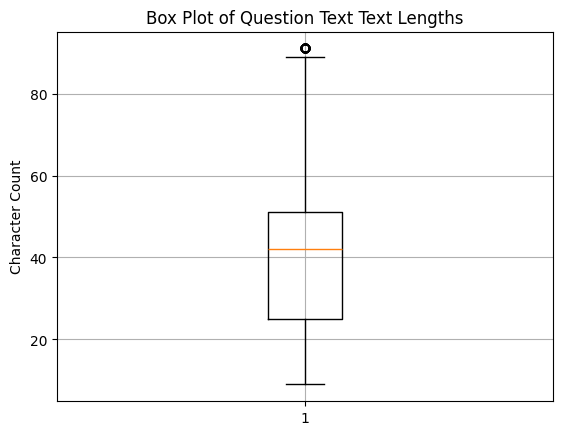

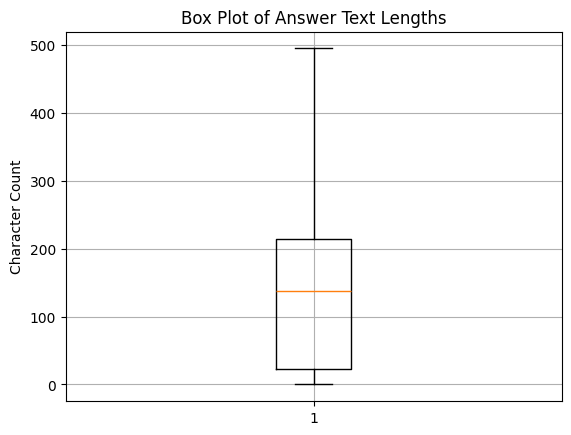







21:53:22 [INFO    ]: 

-------- Plant Expert VQA Training Dataset Class Frequency Distributions --------




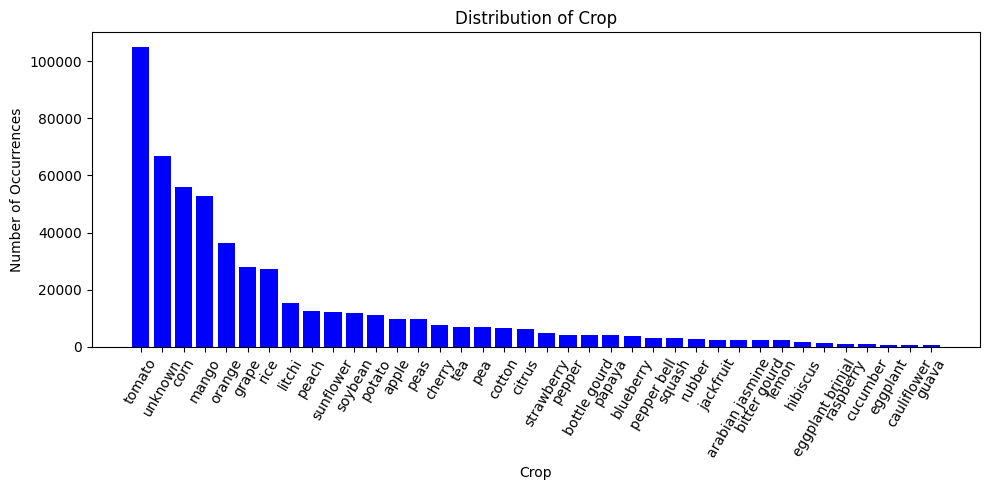

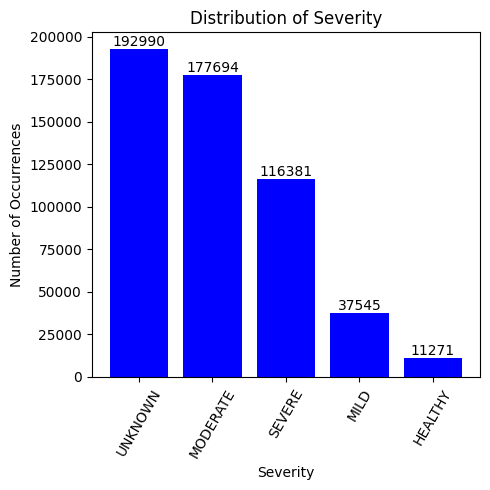

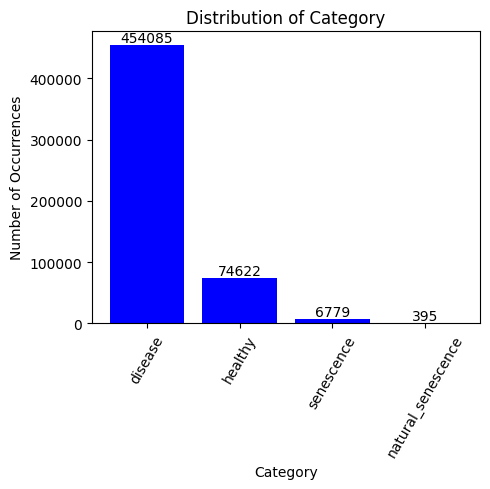

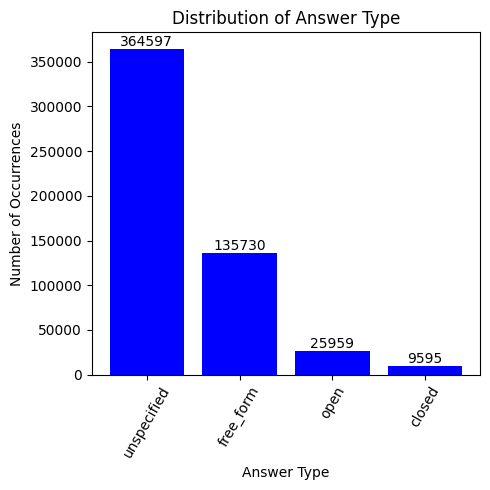

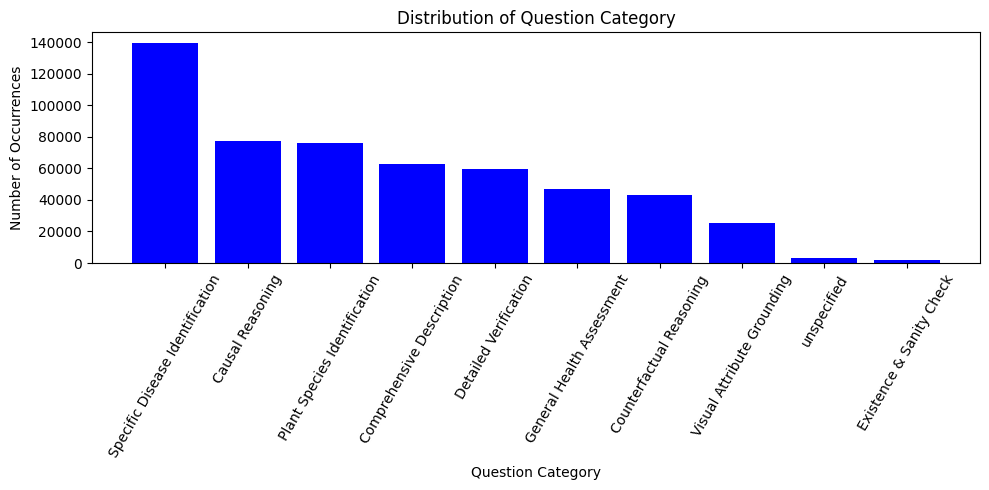







21:53:22 [INFO    ]: 

-------- Plant Expert VQA Training Dataset WordClouds --------




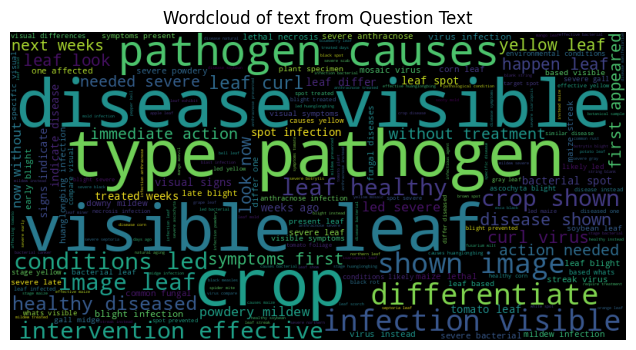

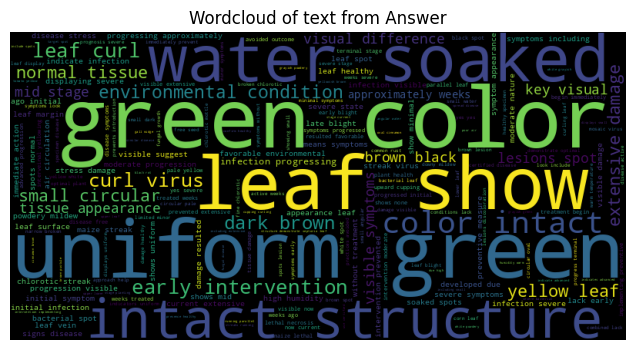







21:53:33 [INFO    ]: 

-------- Plant Expert VQA Training Dataset Word Frequency Distributions --------




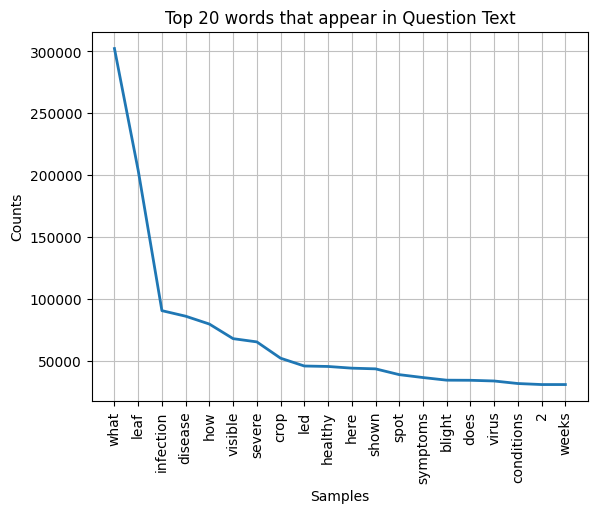

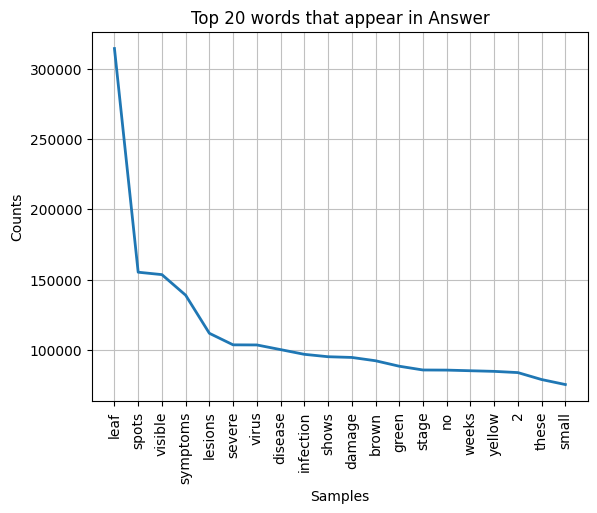

In [7]:

column_distribution_args= [
    {"column": "crop", "show_counts": False, "figure_size": (10, 5)},
    {"column": "severity", "show_counts": True, "figure_size": (5, 5)},
    {"column": "category", "show_counts": True, "figure_size": (5, 5)},
    {"column": "answer_type", "show_counts": True, "figure_size": (5, 5)},
    {"column": "question_category", "show_counts": False, "figure_size": (10, 5)},
]

# explore the cleaned training dataset
text_explore.explore_data(
    plant_expert_vqa_TRAIN, 
    column_distribution_args, 
    PEVQA_text_columns, 
    top_n_words=20, 
    name="Plant Expert VQA Training Dataset"
)

In [8]:
# Testing the tokenizer and showing how to use it

# intialize the tokenizer
tokenizer= TextTokenizer("distilbert-base-uncased", 128)

# example of the passing in a single string to tokenize
inputs, attention_mask= tokenizer.encode_text("hello")
Logger.info(inputs)

# how to decode a single tensor output
output= tokenizer.decode(inputs)
Logger.info(output)

# encoding a list of strings
inputs, attention_mask= tokenizer.encode_text(["hello", "this is a test", "i am putting in multiple strings"])
Logger.info(inputs)

# decoding a list of tensors
output= tokenizer.batch_decode(inputs)
Logger.info(output)

# encoding a column of data
questions= plant_expert_vqa_TRAIN["question_text"]
inputs, attention_mask= tokenizer.encode_text(questions)

# decoding a all of those tensors
output= tokenizer.batch_decode(inputs)
Logger.info(f"first few decoded Tensors: \n\n{output[:10]}")


21:53:36 [INFO    ]: tf.Tensor([[ 101 7592  102]], shape=(1, 3), dtype=int64)
21:53:36 [INFO    ]: ['hello']
21:53:36 [INFO    ]: tf.Tensor(
[[ 101 7592  102    0    0    0    0    0]
 [ 101 2023 2003 1037 3231  102    0    0]
 [ 101 1045 2572 5128 1999 3674 7817  102]], shape=(3, 8), dtype=int64)
21:53:36 [INFO    ]: ['hello', 'this is a test', 'i am putting in multiple strings']
21:53:49 [INFO    ]: first few decoded Tensors: 

['what disease shown here', 'how severe gourd anthracnose infection', 'what led severe gourd anthracnose infection', 'gourd anthracnose treated 5 7 days ago when symptoms first appeared how leaf look now', 'without treatment what happen leaf over next 1 2 weeks', 'what immediate action needed severe gourd anthracnose', 'severe gourd anthracnose prevented', 'what disease shown here', 'how severe gourd anthracnose infection', 'what led severe gourd anthracnose infection']


In [ ]:
# Adding on macbook - will need to retest on workstation later tonight due to GPU acceleration
IMAGES_ROOT = DATA_DIR / "PlantExpertVQA"
traits = ["crop", "disease", "category", "severity"]

classes = {}
for t in traits:
    names = sorted(plant_expert_vqa_TRAIN[t].unique())  # adds names of plants
    classes[t] = names + ["unknown"]  # adds unknown species

train_ds = VisualModel.make_dataset(plant_expert_vqa_TRAIN, classes, IMAGES_ROOT, training=True)
val_ds = VisualModel.make_dataset(plant_expert_vqa_VAL, classes, IMAGES_ROOT)

visual_model = VisualModel(classes=classes)
visual_model.build()
visual_model.compile()
visual_model.fit(train_ds, val_ds, epochs=20)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 16s 1us/step
Epoch 1/20
  442/16747 ━━━━━━━━━━━━━━━━━━━━ 1:12:03 265ms/step - category_accuracy: 0.9715 - category_loss: 0.1175 - crop_accuracy: 0.9036 - crop_loss: 0.5036 - disease_accuracy: 0.6886 - disease_loss: 1.4041 - loss: 2.0898 - severity_accuracy: 0.8410 - severity_loss: 0.4895

In [ ]:
import json
Path("./models/visual_models/9_10_classes.json").write_text(json.dumps(classes))
visual_model.save(path="./models/visual_models/9_10.keras")